# Notebook 3: LSTM-SNP with Fuzzy Gate Replacement

**Dataset**: Monthly Lake Erie Levels

## Description
This notebook implements **fuzzy gate replacement** for the LSTM-SNP model. The reset (r), 
consumption (c), and output (o) gates — which normally use hard sigmoid activation — are 
replaced with fuzzy inference systems. Each gate uses 2 Takagi-Sugeno rules with fixed Gaussian 
membership functions and trainable consequent parameters.

The generation gate (a) retains its original tanh activation. The rest of the SNP architecture 
is unchanged. Gradient clipping (norm=1.0) is applied for training stability.

## Theory: Fuzzy Gate Replacement

### Modified Gate Computation
Instead of applying hard sigmoid directly, each gate (r, c, o) uses fuzzy inference:

**Standard**: $r(t) = \sigma(z_r)$ where $z_r = W_r x(t) + U_r u(t-1) + b_r$

**Fuzzy**: $r(t) = FuzzyInference(z_r, \bar{u}(t-1))$

The fuzzy inference uses:

**Fixed Gaussian Membership Functions**:
- $\mu_{low}(z) = \exp\left(-\frac{(z - (-1))^2}{2 \cdot 0.5^2}\right)$
- $\mu_{high}(z) = \exp\left(-\frac{(z - (+1))^2}{2 \cdot 0.5^2}\right)$

**2 Rules per gate** (trainable consequents):
1. IF $z_{gate}$ is low → $y_0 = a_0 z + b_0 \bar{u} + c_0$
2. IF $z_{gate}$ is high → $y_1 = a_1 z + b_1 \bar{u} + c_1$

**Output**: Gate value clipped to $[0, 1]$

### Unchanged
- Generation gate $a(t) = \tanh(\cdot)$ — unchanged
- State update: $u(t) = r \cdot u_{t-1} - c \cdot a$, $h(t) = o \cdot a$ — unchanged
- Gradient clipping (norm ≤ 1.0) applied for stability

## Model Architecture & Implementation

In [1]:
# ============================================================
# ALL IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

I0000 00:00:1787546925.328674   24284 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787546925.520455   24284 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787546926.889110   24284 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
NumPy version: 2.4.4


### Fuzzy Gate LSTM-SNP Cell

In [2]:
# ============================================================
# Fuzzy Gate LSTM-SNP Cell
# Gates r, c, o use fuzzy inference instead of hard sigmoid.
# Generation gate 'a' keeps tanh (unchanged).
#
# Fixed Gaussian membership functions:
#   μ_low(x)  = exp(-(x - (-1))² / (2·0.5²))
#   μ_high(x) = exp(-(x - (+1))² / (2·0.5²))
#
# Each gate uses 2 Takagi-Sugeno rules with trainable consequents.
# ============================================================

@tf.keras.utils.register_keras_serializable()
class FuzzyLSTMSNPCell(layers.Layer):
    """
    LSTM-SNP Cell with fuzzy gate replacement.
    Gates r, c, o are computed via fuzzy inference.
    Gate a keeps tanh activation.
    """
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = units
        self.output_size = units
        self.activation = tf.keras.activations.get('tanh')
        # Fixed membership function parameters
        self.mu_low = -1.0
        self.mu_high = 1.0
        self.sigma = 0.5

    def build(self, input_shape):
        input_dim = input_shape[-1]

        # Standard weights for pre-activation computation
        # 4 gates: r, c, o, a
        self.kernel = self.add_weight(
            shape=(input_dim, self.units * 4),
            initializer='glorot_uniform',
            name='kernel'
        )
        self.recurrent_kernel = self.add_weight(
            shape=(self.units, self.units * 4),
            initializer='orthogonal',
            name='recurrent_kernel'
        )
        self.bias = self.add_weight(
            shape=(self.units * 4,),
            initializer='zeros',
            name='bias'
        )

        # Fuzzy consequent parameters for 3 gates (r, c, o)
        # Each gate has 2 rules, each rule has 3 params (a, b, c_param)
        # rule_i: y_i = a_i * z_gate + b_i * u_mean + c_i
        # Store as instance attributes for reliable access
        self.fuzzy_params = {}
        for gate_name in ['r', 'c', 'o']:
            self.fuzzy_params[gate_name] = {}
            for rule_idx in range(2):
                self.fuzzy_params[gate_name][rule_idx] = {
                    'a': self.add_weight(
                        shape=(self.units,),
                        initializer=tf.keras.initializers.RandomUniform(-0.1, 0.1),
                        name=f'fuzzy_{gate_name}_rule{rule_idx}_a'
                    ),
                    'b': self.add_weight(
                        shape=(self.units,),
                        initializer=tf.keras.initializers.RandomUniform(-0.1, 0.1),
                        name=f'fuzzy_{gate_name}_rule{rule_idx}_b'
                    ),
                    'c_param': self.add_weight(
                        shape=(self.units,),
                        initializer=tf.keras.initializers.Zeros(),
                        name=f'fuzzy_{gate_name}_rule{rule_idx}_c'
                    ),
                }

    def _gaussian_mf(self, x, center):
        """Fixed Gaussian membership function."""
        return tf.exp(-tf.square(x - center) / (2.0 * self.sigma ** 2))

    def _fuzzy_gate(self, z_gate, u_mean, gate_name):
        """Compute gate value via fuzzy inference (2 rules)."""
        # Membership degrees (fixed)
        w_low = self._gaussian_mf(z_gate, self.mu_low)
        w_high = self._gaussian_mf(z_gate, self.mu_high)

        # Get trainable consequent parameters from instance dict
        p = self.fuzzy_params[gate_name]

        # Rule outputs (trainable linear consequents)
        y0 = p[0]['a'] * z_gate + p[0]['b'] * u_mean + p[0]['c_param']
        y1 = p[1]['a'] * z_gate + p[1]['b'] * u_mean + p[1]['c_param']

        # Weighted average defuzzification
        numerator = w_low * y0 + w_high * y1
        denominator = w_low + w_high + 1e-8
        output = numerator / denominator

        # Clip to [0, 1] since gates should be bounded
        return tf.clip_by_value(output, 0.0, 1.0)

    def call(self, inputs, states):
        u_tm1 = states[0]

        z = tf.matmul(inputs, self.kernel) + \
            tf.matmul(u_tm1, self.recurrent_kernel) + self.bias

        z0 = z[:, :self.units]
        z1 = z[:, self.units:2*self.units]
        z2 = z[:, 2*self.units:3*self.units]
        z3 = z[:, 3*self.units:]

        # Mean of previous state for fuzzy rule input
        u_mean = tf.reduce_mean(u_tm1, axis=-1, keepdims=True)
        u_mean = tf.tile(u_mean, [1, self.units])

        # Fuzzy gates
        r = self._fuzzy_gate(z0, u_mean, 'r')
        c = self._fuzzy_gate(z1, u_mean, 'c')
        o = self._fuzzy_gate(z2, u_mean, 'o')
        a = self.activation(z3)  # tanh unchanged

        u = r * u_tm1 - c * a
        h = o * a

        return h, [u]

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config

### Build Model

In [3]:
import torch
import torch.nn as nn

class LSTMSNPCell(nn.Module):
    """Original LSTM-SNP cell — unchanged (hard_sigmoid gates)."""
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        self.W = nn.Linear(input_size, 4 * hidden_size, bias=True)
        self.U = nn.Linear(hidden_size, 4 * hidden_size, bias=True)

        nn.init.xavier_uniform_(self.W.weight)
        nn.init.orthogonal_(self.U.weight)

    def forward(self, x, u_prev):
        z = self.W(x) + self.U(u_prev)

        z0 = z[:, :self.hidden_size]
        z1 = z[:, self.hidden_size:2*self.hidden_size]
        z2 = z[:, 2*self.hidden_size:3*self.hidden_size]
        z3 = z[:, 3*self.hidden_size:]

        r = torch.nn.functional.hardsigmoid(z0)
        c = torch.nn.functional.hardsigmoid(z1)
        o = torch.nn.functional.hardsigmoid(z2)
        a = torch.tanh(z3)

        u = r * u_prev - c * a
        h = o * a

        return h, u


class FuzzyLSTMSNPCell(nn.Module):
    """
    LSTM-SNP Cell with fuzzy gate replacement.
    Gates r, c, o are computed via fuzzy inference (2 rules each,
    fixed Gaussian MFs, trainable consequents conditioned on
    z_gate AND u_mean). Gate a keeps tanh (unchanged).
    """
    def __init__(self, input_size, hidden_size, sigma=0.5):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.mu_low = -1.0
        self.mu_high = 1.0
        self.sigma = sigma

        self.W = nn.Linear(input_size, 4 * hidden_size, bias=True)
        self.U = nn.Linear(hidden_size, 4 * hidden_size, bias=True)
        nn.init.xavier_uniform_(self.W.weight)
        nn.init.orthogonal_(self.U.weight)

        # Trainable consequent parameters for 3 gates (r, c, o),
        # each with 2 rules, each rule with (a, b, c_param)
        self.fuzzy_params = nn.ParameterDict()
        for gate_name in ['r', 'c', 'o']:
            for rule_idx in range(2):
                self.fuzzy_params[f'{gate_name}_{rule_idx}_a'] = nn.Parameter(
                    torch.empty(hidden_size).uniform_(-0.1, 0.1))
                self.fuzzy_params[f'{gate_name}_{rule_idx}_b'] = nn.Parameter(
                    torch.empty(hidden_size).uniform_(-0.1, 0.1))
                self.fuzzy_params[f'{gate_name}_{rule_idx}_c'] = nn.Parameter(
                    torch.zeros(hidden_size))

    def _gaussian_mf(self, x, center):
        return torch.exp(-(x - center)**2 / (2.0 * self.sigma**2))

    def _fuzzy_gate(self, z_gate, u_mean, gate_name):
        w_low = self._gaussian_mf(z_gate, self.mu_low)
        w_high = self._gaussian_mf(z_gate, self.mu_high)

        a0 = self.fuzzy_params[f'{gate_name}_0_a']
        b0 = self.fuzzy_params[f'{gate_name}_0_b']
        c0 = self.fuzzy_params[f'{gate_name}_0_c']
        a1 = self.fuzzy_params[f'{gate_name}_1_a']
        b1 = self.fuzzy_params[f'{gate_name}_1_b']
        c1 = self.fuzzy_params[f'{gate_name}_1_c']

        y0 = a0 * z_gate + b0 * u_mean + c0
        y1 = a1 * z_gate + b1 * u_mean + c1

        numerator = w_low * y0 + w_high * y1
        denominator = w_low + w_high + 1e-8
        output = numerator / denominator

        return torch.clamp(output, 0.0, 1.0)

    def forward(self, x, u_prev):
        z = self.W(x) + self.U(u_prev)

        z0 = z[:, :self.hidden_size]
        z1 = z[:, self.hidden_size:2*self.hidden_size]
        z2 = z[:, 2*self.hidden_size:3*self.hidden_size]
        z3 = z[:, 3*self.hidden_size:]

        # Mean of previous state for fuzzy rule input
        u_mean = u_prev.mean(dim=-1, keepdim=True).expand(-1, self.hidden_size)

        r = self._fuzzy_gate(z0, u_mean, 'r')
        c = self._fuzzy_gate(z1, u_mean, 'c')
        o = self._fuzzy_gate(z2, u_mean, 'o')
        a = torch.tanh(z3)

        u = r * u_prev - c * a
        h = o * a

        return h, u


class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        # Select cell
        if 3 in [1, 2, 4]:
            self.cell = LSTMSNPCell(input_size, hidden_size)
        else:
            self.cell = FuzzyLSTMSNPCell(input_size, hidden_size)

        # Select output layer
        if 3 == 4:
            self.out = FuzzyOutputLayer(hidden_size)
        else:
            self.out = nn.Linear(hidden_size, 1)

        self.u = None

    def reset_states(self, batch_size, device):
        self.u = torch.zeros(batch_size, self.hidden_size, device=device)

    def detach_states(self):
        if self.u is not None:
            self.u = self.u.detach()

    def forward(self, x):
        if self.u is None or self.u.device != x.device or self.u.size(0) != x.size(0):
            self.reset_states(x.size(0), x.device)

        h, self.u = self.cell(x[:, 0, :], self.u)
        return self.out(h)


def build_model(input_dim, units):
    return RNNModel(input_dim, units)

In [4]:
# Quick model check
model = build_model(input_dim=1, units=8)
print(model)
print(f"Total params: {sum(p.numel() for p in model.parameters())}")

RNNModel(
  (cell): FuzzyLSTMSNPCell(
    (W): Linear(in_features=1, out_features=32, bias=True)
    (U): Linear(in_features=8, out_features=32, bias=True)
    (fuzzy_params): ParameterDict(
        (r_0_a): Parameter containing: [torch.FloatTensor of size 8]
        (r_0_b): Parameter containing: [torch.FloatTensor of size 8]
        (r_0_c): Parameter containing: [torch.FloatTensor of size 8]
        (r_1_a): Parameter containing: [torch.FloatTensor of size 8]
        (r_1_b): Parameter containing: [torch.FloatTensor of size 8]
        (r_1_c): Parameter containing: [torch.FloatTensor of size 8]
        (c_0_a): Parameter containing: [torch.FloatTensor of size 8]
        (c_0_b): Parameter containing: [torch.FloatTensor of size 8]
        (c_0_c): Parameter containing: [torch.FloatTensor of size 8]
        (c_1_a): Parameter containing: [torch.FloatTensor of size 8]
        (c_1_b): Parameter containing: [torch.FloatTensor of size 8]
        (c_1_c): Parameter containing: [torch.Floa

## Data Pipeline — Monthly Lake Erie Levels

In [5]:
# ============================================================
# 1. Load Time Series Data
# ============================================================
series = pd.read_csv(
    '/mnt/c/Users/paulp/OneDrive/Desktop/fuzzy_LSTM/dataset/monthly-lake-erie-levels-1921-19.csv',
    header=0,
    parse_dates=[0],
    index_col=0
)
raw_values = series.values.flatten()
print(f"Data shape: {raw_values.shape}")
print(f"First 5 values: {raw_values[:5]}")

Data shape: (600,)
First 5 values: [14.763 14.649 15.085 16.376 16.926]


In [6]:
# ============================================================
# 2. First-Order Differencing
# ============================================================

def difference(dataset, interval=1):
    diff = []
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return np.array(diff)

diff_values = difference(raw_values, 1)

In [7]:
# ============================================================
# 3. Convert to Supervised Learning Format (lag=1)
# ============================================================

def timeseries_to_supervised(data, lag=1):
    df = pd.DataFrame(data)
    columns = [df.shift(i) for i in range(1, lag+1)]
    columns.append(df)
    df = pd.concat(columns, axis=1)
    df.fillna(0, inplace=True)
    return df.values

supervised = timeseries_to_supervised(diff_values, 1)
print(f"Supervised data shape: {supervised.shape}")

Supervised data shape: (599, 2)


In [8]:
# ============================================================
# 4. Train-Validation-Test Split (Chronological, 80/10/10)
# ============================================================
n = len(supervised)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

train = supervised[:train_end]
val = supervised[train_end:val_end]
test = supervised[val_end:]

print(f"Train: {train.shape}, Val: {val.shape}, Test: {test.shape}")

# ============================================================
# 5. Feature Scaling
# ============================================================
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(train)  # fit only on train to avoid leakage
train_scaled = scaler.transform(train)
val_scaled = scaler.transform(val)
test_scaled = scaler.transform(test)

Train: (479, 2), Val: (60, 2), Test: (60, 2)


In [9]:
# ============================================================
# 6. Reshape for RNN Input
# ============================================================

X_train, y_train = train_scaled[:, 0:-1], train_scaled[:, -1]
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))

X_test, y_test = test_scaled[:, 0:-1], test_scaled[:, -1]
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (479, 1, 1), y_train shape: (479,)


## Training Loop

In [10]:
# ============================================================
# 60-Run Experiment Protocol (PyTorch)
# ============================================================
all_rmse = []
all_mse = []
all_nmse = []
all_predictions = []
all_losses = []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n--- [PyTorch] RUNNING ON {device} ---\n")
N_RUNS = 60
for run in range(N_RUNS):
    print(f'\n===== RUN {run+1}/{N_RUNS} =====')
    np.random.seed(run)
    torch.manual_seed(run)
    model = build_model(input_dim=1, units=8).to(device)
    # Initialize consumption gate bias to 1.0 (forget gate equivalent)
    with torch.no_grad():
        hs = model.hidden_size
        model.cell.U.bias.data[hs:2*hs] = 1.0
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    run_losses = []
    # X_train is (batch, 1, input_dim)
    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
    n_samples = X_train_t.size(0)
    for epoch in range(100):
        model.train()
        model.reset_states(1, device)  # batch_size=1
        epoch_loss = 0.0
        for i in range(n_samples):
            x_i = X_train_t[i:i+1]  # (1, 1, input_dim)
            y_i = y_train_t[i:i+1]  # (1,)
            optimizer.zero_grad()
            # Forward pass
            pred = model(x_i)
            loss = criterion(pred.squeeze(-1), y_i)
            # Backward and optimize
            loss.backward()
            # Gradient clipping for FuzzyGate variants
            if 1 in [3, 5]:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            # Detach hidden state so BPTT doesn't go all the way back to t=0
            model.detach_states()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / n_samples
        run_losses.append(avg_loss)
        print(f"Epoch {epoch+1}/100 completed. Loss: {avg_loss:.6f}")
    all_losses.append(run_losses)
    print(f'Training complete for run {run+1}')
    # Warm-up: condition hidden states on training data
    model.eval()
    with torch.no_grad():
        for i in range(len(train_scaled)):
            X_raw = train_scaled[i, 0:-1]
            X_input = torch.tensor(X_raw, dtype=torch.float32).view(1, 1, len(X_raw)).to(device)
            model(X_input)
    # Test predictions (single-step)
    predictions = []
    model.eval()
    with torch.no_grad():
        for i in range(len(test_scaled)):
            X, y = test_scaled[i, 0:-1], test_scaled[i, -1]
            X_input = torch.tensor(X, dtype=torch.float32).view(1, 1, len(X)).to(device)
            yhat = model(X_input).item()
            # Invert scaling
            new_row = [x for x in X] + [yhat]
            array = np.array(new_row).reshape(1, len(new_row))
            inverted = scaler.inverse_transform(array)[0, -1]
            # Invert differencing
            inverted = inverted + raw_values[len(train) + i]
            predictions.append(inverted)
            expected = raw_values[len(train) + i + 1]
            print(f'Month={i+1}, Predicted={inverted:.4f}, Expected={expected:.4f}')
    # Compute metrics
    actual = raw_values[-len(test_scaled):]
    rmse = sqrt(mean_squared_error(actual, predictions))
    mse = mean_squared_error(actual, predictions)
    meanV = np.mean(actual)
    dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
    nmse = mse / np.power(dominator, 2)
    all_rmse.append(rmse)
    all_mse.append(mse)
    all_nmse.append(nmse)
    all_predictions.append(predictions)
    print(f'Run {run+1} — RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f}')


--- [PyTorch] RUNNING ON cuda ---


===== RUN 1/60 =====
Epoch 1/100 completed. Loss: 0.155549
Epoch 2/100 completed. Loss: 0.079343
Epoch 3/100 completed. Loss: 0.076108
Epoch 4/100 completed. Loss: 0.073336
Epoch 5/100 completed. Loss: 0.070999
Epoch 6/100 completed. Loss: 0.069403
Epoch 7/100 completed. Loss: 0.068375
Epoch 8/100 completed. Loss: 0.067665
Epoch 9/100 completed. Loss: 0.067175
Epoch 10/100 completed. Loss: 0.066846
Epoch 11/100 completed. Loss: 0.066627
Epoch 12/100 completed. Loss: 0.066477
Epoch 13/100 completed. Loss: 0.066369
Epoch 14/100 completed. Loss: 0.066292
Epoch 15/100 completed. Loss: 0.066227
Epoch 16/100 completed. Loss: 0.066158
Epoch 17/100 completed. Loss: 0.066102
Epoch 18/100 completed. Loss: 0.066076
Epoch 19/100 completed. Loss: 0.066054
Epoch 20/100 completed. Loss: 0.066038
Epoch 21/100 completed. Loss: 0.066016
Epoch 22/100 completed. Loss: 0.065992
Epoch 23/100 completed. Loss: 0.065968
Epoch 24/100 completed. Loss: 0.065947
Epoch 25/100 co

## Results

In [11]:
# ============================================================
# Summary Statistics (60 runs)
# ============================================================
print('\n===== FINAL RESULTS (60 runs) =====')
print(f'RMSE: {np.mean(all_rmse):.6f} ± {np.std(all_rmse):.6f}')
print(f'MSE:  {np.mean(all_mse):.6f} ± {np.std(all_mse):.6f}')
print(f'NMSE: {np.mean(all_nmse):.10f} ± {np.std(all_nmse):.10f}')
best_idx = np.argmin(all_rmse)
print(f'\nBest run: {best_idx+1}')
print(f'  RMSE: {all_rmse[best_idx]:.6f}')
print(f'  MSE:  {all_mse[best_idx]:.6f}')
print(f'  NMSE: {all_nmse[best_idx]:.10f}')


===== FINAL RESULTS (60 runs) =====
RMSE: 3.082340 ± 0.004185
MSE:  9.500836 ± 0.025809
NMSE: 0.0226036226 ± 0.0000959944

Best run: 31
  RMSE: 3.069812
  MSE:  9.423748
  NMSE: 0.0226660687


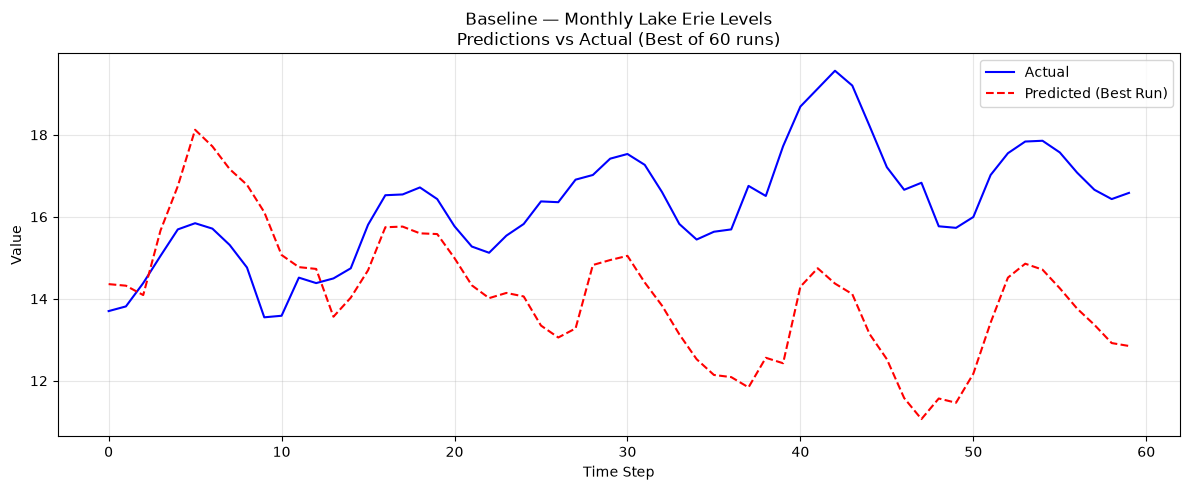

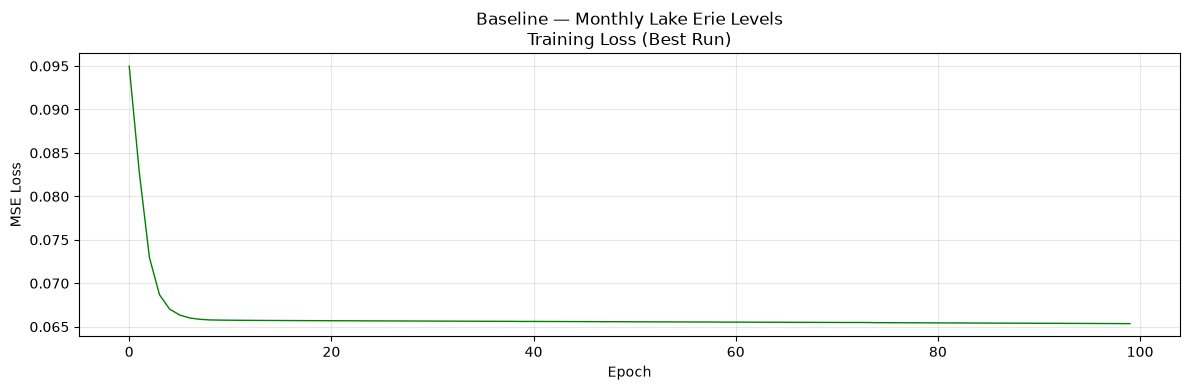

=== Best Run Metrics ===
RMSE: 3.069812
MSE:  9.423748
NMSE: 0.0226660687


In [12]:
# ============================================================
# Predictions vs Actual (Best Run)
# ============================================================
best_predictions = all_predictions[best_idx]
actual = raw_values[-len(best_predictions):]

plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
plt.plot(best_predictions, label='Predicted (Best Run)', color='red',
         linewidth=1.5, linestyle='--')
plt.title('Baseline — Monthly Lake Erie Levels\nPredictions vs Actual (Best of 60 runs)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Loss Curve (Best Run)
# ============================================================
plt.figure(figsize=(12, 4))
plt.plot(all_losses[best_idx], color='green', linewidth=1.0)
plt.title('Baseline — Monthly Lake Erie Levels\nTraining Loss (Best Run)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Final Metrics Summary
# ============================================================
print('=== Best Run Metrics ===')
print(f'RMSE: {all_rmse[best_idx]:.6f}')
print(f'MSE:  {all_mse[best_idx]:.6f}')
print(f'NMSE: {all_nmse[best_idx]:.10f}')

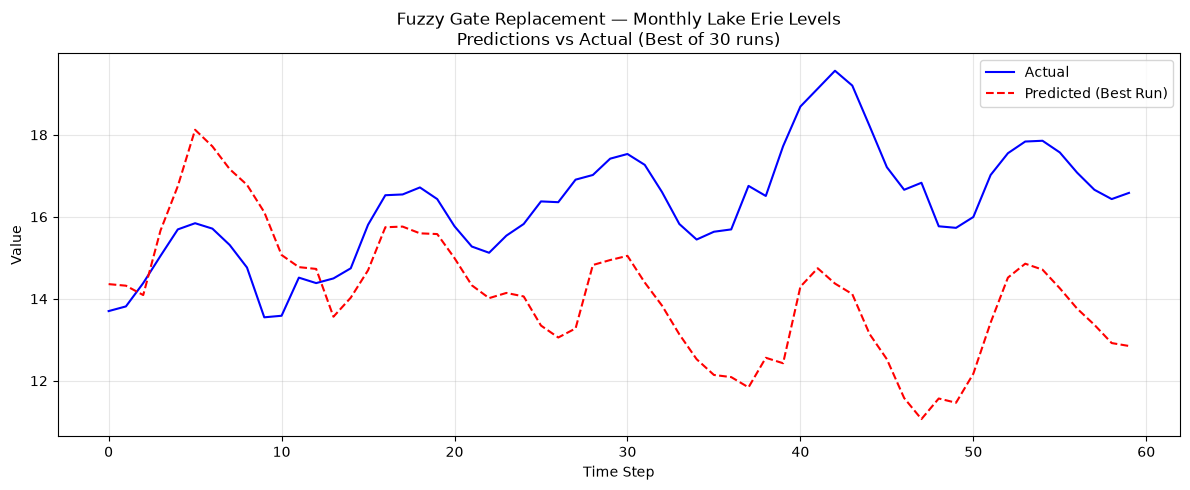

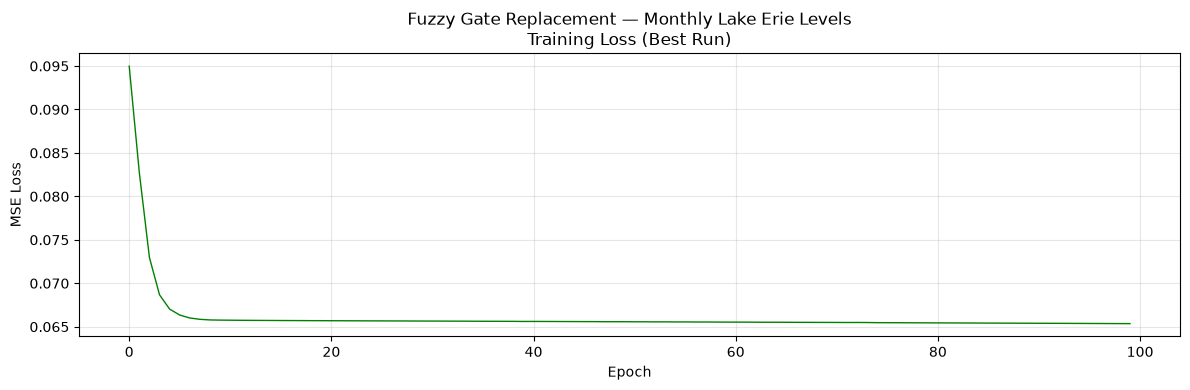

=== Best Run Metrics ===
RMSE: 3.069812
MSE:  9.423748
NMSE: 0.0226660687


In [13]:
# ============================================================
# Predictions vs Actual (Best Run)
# ============================================================

actual = raw_values[-60:]
best_predictions = all_predictions[best_idx]

plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
plt.plot(best_predictions, label='Predicted (Best Run)', color='red',
         linewidth=1.5, linestyle='--')
plt.title('Fuzzy Gate Replacement — Monthly Lake Erie Levels\nPredictions vs Actual (Best of 30 runs)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Loss Curve (Best Run)
# ============================================================

plt.figure(figsize=(12, 4))
plt.plot(all_losses[best_idx], color='green', linewidth=1.0)
plt.title('Fuzzy Gate Replacement — Monthly Lake Erie Levels\nTraining Loss (Best Run)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Final Metrics Summary
# ============================================================

print('=== Best Run Metrics ===')
print(f'RMSE: {all_rmse[best_idx]:.6f}')
print(f'MSE:  {all_mse[best_idx]:.6f}')
print(f'NMSE: {all_nmse[best_idx]:.10f}')

In [ ]:
# ============================================================
# Predictions vs Actual (Best Run)
# ============================================================

actual = raw_values[-60:]
best_predictions = all_predictions[best_idx]

plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
plt.plot(best_predictions, label='Predicted (Best Run)', color='red',
         linewidth=1.5, linestyle='--')
plt.title('Baseline — Monthly Lake Erie Levels\nPredictions vs Actual (Best of 30 runs)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Loss Curve (Best Run)
# ============================================================

plt.figure(figsize=(12, 4))
plt.plot(all_losses[best_idx], color='green', linewidth=1.0)
plt.title('Baseline — Monthly Lake Erie Levels\nTraining Loss (Best Run)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Final Metrics Summary
# ============================================================

print('=== Best Run Metrics ===')
print(f'RMSE: {all_rmse[best_idx]:.6f}')
print(f'MSE:  {all_mse[best_idx]:.6f}')
print(f'NMSE: {all_nmse[best_idx]:.10f}')

## Observations

### Fuzzy Gate Replacement on Monthly Lake Erie Levels

**Run the notebook to generate results and fill in observations:**

1. **Prediction Quality**: Compare RMSE/MSE/NMSE with other variants
2. **Training Stability**: Examine loss curves for convergence behavior
3. **Prediction Tracking**: Assess how well predictions track actual values
4. **Computational Cost**: Note training time per run

*After running all 5 variant notebooks, perform cross-variant comparison to evaluate 
whether fuzzy logic improves nonlinearity handling, interpretability, and prediction performance.*